<a href="https://colab.research.google.com/github/swaraa25/cow_classifier/blob/main/Indigenous_Cattle_Breed_Classifier_presentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Indigenous Cattle Breed Classifier — Presentation Notebook

This notebook EDA, background-removal,
feature visualizations (feature maps, Grad-CAM, t-SNE), and a multi-model comparison workflow.

**Dataset path used:** `/content/drive/MyDrive/cattle_images_whole` (Google Drive / Colab).


In [ ]:
# Setup
!pip install rembg onnxruntime --quiet
!pip install grad-cam --quiet
!pip install torchmetrics --quiet

from google.colab import drive
drive.mount('/content/drive')

import os, torch, random, numpy as np, matplotlib.pyplot as plt
print("Torch version:", torch.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 91.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 19.9 MB/s eta 0:00:00
Mounted at /content/drive
Torch version: 2.8.0+cu126


In [ ]:
# DATA PATH (adjust if different)
DATA_DIR = "/content/drive/MyDrive/cattle_images_whole"
CLEAN_DIR = "/content/drive/MyDrive/cattle_images_cleaned"
USE_CLEANED = False
ROOT = CLEAN_DIR if USE_CLEANED else DATA_DIR
print("Dataset root:", ROOT)
# assert os.path.exists(ROOT), f"Path not found: {ROOT}"

Dataset root: /content/drive/MyDrive/cattle_images_whole


In [ ]:
# Validate images utility (optional)
from PIL import Image
import os
def validate_and_remove_images(root_folder):
    removed = 0
    for dirpath, dirnames, filenames in os.walk(root_folder):
        for filename in filenames:
            if not filename.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tiff','.tif')):
                continue
            file_path = os.path.join(dirpath, filename)
            try:
                img = Image.open(file_path); img.verify()
            except Exception:
                try:
                    os.remove(file_path); removed += 1
                except:
                    pass
    print('Removed corrupt images:', removed)

# validate_and_remove_images(ROOT)

Classes: ['Alambadi', 'Amritmahal', 'Ayrshire', 'Banni', 'Bargur', 'Bhadawari', 'Brown_Swiss', 'Dangi', 'Deoni', 'Gir', 'Guernsey', 'Hallikar', 'Hariana', 'Holstein_Friesian', 'Jaffrabadi', 'Jersey', 'Kangayam', 'Kankrej', 'Kasargod', 'Kenkatha', 'Kherigarh', 'Khillari', 'Krishna_Valley', 'Malnad_gidda', 'Mehsana', 'Murrah', 'Nagori', 'Nagpuri', 'Nili_Ravi', 'Nimari', 'Ongole', 'Pulikulam', 'Rathi', 'Red_Dane', 'Red_Sindhi', 'Sahiwal', 'Surti', 'Tharparkar', 'Toda', 'Umblachery', 'Vechur']
Class counts: Counter({35: 432, 9: 343, 13: 327, 2: 234, 6: 223, 37: 207, 15: 198, 30: 185, 11: 182, 17: 175, 27: 175, 33: 159, 25: 158, 34: 157, 32: 143, 22: 135, 40: 128, 12: 127, 31: 119, 10: 117, 38: 115, 21: 103, 23: 102, 3: 99, 14: 99, 0: 98, 8: 98, 18: 94, 4: 93, 16: 91, 1: 90, 24: 90, 5: 86, 28: 86, 29: 84, 7: 82, 26: 82, 39: 71, 19: 52, 36: 44, 20: 29})


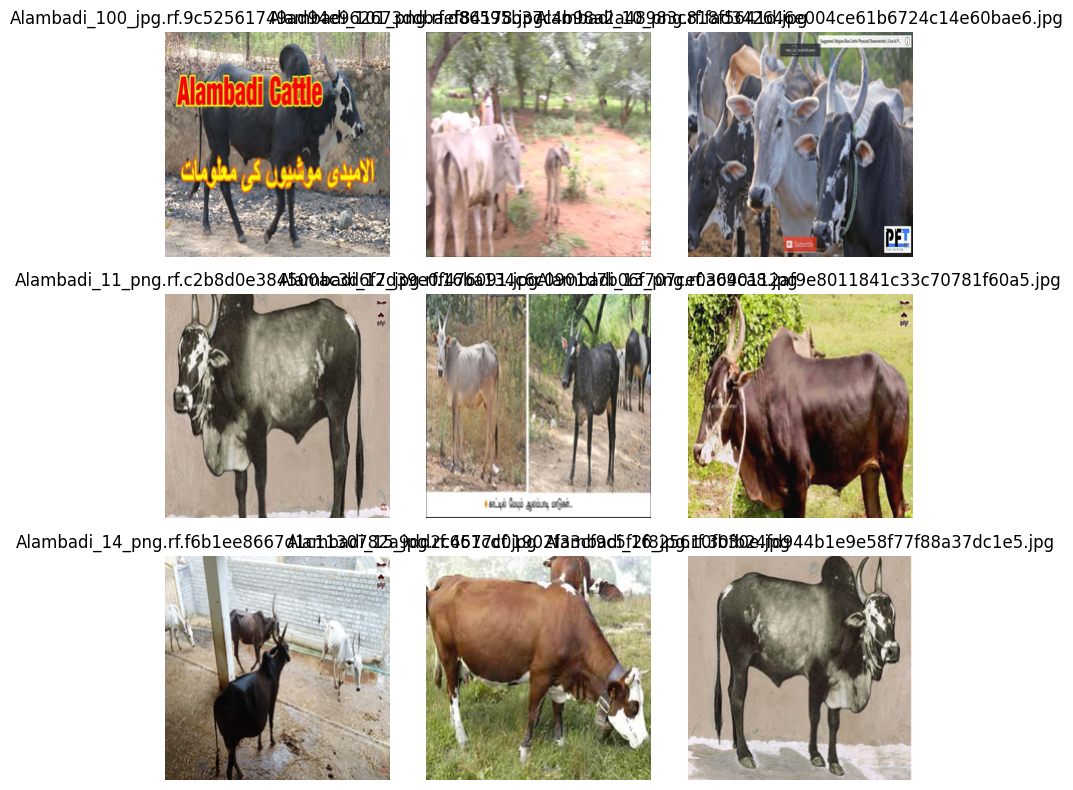

In [ ]:
# EDA: show class counts and sample images
from torchvision.datasets import ImageFolder
from collections import Counter
from PIL import Image
dataset_check = ImageFolder(ROOT)
print("Classes:", dataset_check.classes)
labels = [lab for _, lab in dataset_check.samples]
print("Class counts:", Counter(labels))

sample_paths = [p for p,_ in dataset_check.samples[:9]]
imgs = [Image.open(p).convert('RGB').resize((224,224)) for p in sample_paths]

import matplotlib.pyplot as plt
def show_grid(images, titles=None, ncols=3, figsize=(8,8)):
    n = len(images); ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    plt.figure(figsize=figsize)
    for i,im in enumerate(images):
        plt.subplot(nrows, ncols, i+1)
        plt.imshow(im)
        if titles: plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout(); plt.show()

show_grid(imgs, titles=[os.path.basename(p) for p in sample_paths])

In [ ]:
# Transforms, dataset and dataloaders
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import random, math
from collections import defaultdict

imagenet_mean = [0.485,0.456,0.406]
imagenet_std  = [0.229,0.224,0.225]

def get_transforms(img_size=224, train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((img_size,img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size,img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
        ])

dataset = ImageFolder(ROOT, transform=get_transforms(train=True))
print('Found classes:', dataset.classes)
print('Total samples:', len(dataset))

def train_test_validation_split(dataset, validation_split_fraction=0.1, test_split_fraction=0.1, seed=42):
    random.seed(seed)
    label_to_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        label_to_indices[label].append(idx)
    train_idx, val_idx, test_idx = [], [], []
    for label, indices in label_to_indices.items():
        n = len(indices)
        if n==0: continue
        n_test = max(1, int(math.floor(test_split_fraction * n)))
        n_val  = max(1, int(math.floor(validation_split_fraction * n)))
        n_train = n - n_val - n_test
        if n_train <= 0:
            n_train = max(1, n - n_val - n_test)
        shuffled = indices[:]; random.shuffle(shuffled)
        train_idx.extend(shuffled[:n_train])
        val_idx.extend(shuffled[n_train:n_train+n_val])
        test_idx.extend(shuffled[n_train+n_val:n_train+n_val+n_test])
    return Subset(dataset, train_idx), Subset(dataset, val_idx), Subset(dataset, test_idx)

train_set, val_set, test_set = train_test_validation_split(dataset, validation_split_fraction=0.1, test_split_fraction=0.1)
batch_size = 8
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)  #CHECKK
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
print('DataLoaders ready. Batch size:', batch_size)

Found classes: ['Alambadi', 'Amritmahal', 'Ayrshire', 'Banni', 'Bargur', 'Bhadawari', 'Brown_Swiss', 'Dangi', 'Deoni', 'Gir', 'Guernsey', 'Hallikar', 'Hariana', 'Holstein_Friesian', 'Jaffrabadi', 'Jersey', 'Kangayam', 'Kankrej', 'Kasargod', 'Kenkatha', 'Kherigarh', 'Khillari', 'Krishna_Valley', 'Malnad_gidda', 'Mehsana', 'Murrah', 'Nagori', 'Nagpuri', 'Nili_Ravi', 'Nimari', 'Ongole', 'Pulikulam', 'Rathi', 'Red_Dane', 'Red_Sindhi', 'Sahiwal', 'Surti', 'Tharparkar', 'Toda', 'Umblachery', 'Vechur']
Total samples: 5712
DataLoaders ready. Batch size: 8


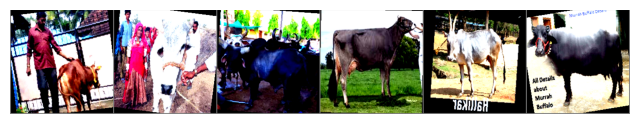

Sample Labels: ['Vechur', 'Tharparkar', 'Kankrej', 'Brown_Swiss', 'Hallikar', 'Murrah']


In [ ]:
# === Data Preprocessing Visualization ===
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision  # <-- Add this import

def imshow(img, title=None):
    img = img / 2 + 0.5  # unnormalize if normalized
    npimg = img.numpy()
    plt.figure(figsize=(8, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Get a batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter) ,

# Show a few sample images
imshow(torchvision.utils.make_grid(images[:6]))
print('Sample Labels:', [dataset.classes[i] for i in labels[:6].tolist()])


In [ ]:
# Model definitions: VanillaCNN and helper for pretrained models
import torch.nn as nn
import torchvision.models as models

class VanillaCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (224//8) * (224//8), 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def get_pretrained_model(pretrained_model_name, num_labels, pretrained=True):
    model = getattr(models, pretrained_model_name)(pretrained=pretrained)

    # Case 1: ResNet-style models
    if hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_labels)
        return model

    # Case 2: Classifier as Sequential (VGG, AlexNet, etc.)
    if hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        last = model.classifier[-1]
        if isinstance(last, nn.Linear):
            in_features = last.in_features
            model.classifier[-1] = nn.Linear(in_features, num_labels)
        return model

    # Case 3: Classifier is a single Linear layer (DenseNet, EfficientNet)
    if hasattr(model, 'classifier') and isinstance(model.classifier, nn.Linear):
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_labels)
        return model

    # Fallback
    print(f"Warning: Custom classifier structure not recognized for {pretrained_model_name}.")
    return model


In [ ]:
# Training helper with checkpointing
from tqdm import tqdm
import torch

def model_training(train_dataloader, validation_dataloader, model_name, model, optimizer, criterion, epochs=5, device=None, scheduler=None, save_path=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    best_val_loss = float('inf')
    best_wts = None
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for inputs, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs = inputs.to(device); labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward(); optimizer.step()
            running += loss.item() * inputs.size(0)
        epoch_loss = running / len(train_dataloader.dataset)
        train_losses.append(epoch_loss)

        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for inputs, labels in validation_dataloader:
                inputs = inputs.to(device); labels = labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running += loss.item() * inputs.size(0)
        val_loss = val_running / len(validation_dataloader.dataset)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}: Train Loss={epoch_loss:.4f} Val Loss={val_loss:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_wts = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            if save_path:
                torch.save(best_wts, save_path)
                print("Saved checkpoint to", save_path)
        if scheduler:
            scheduler.step(val_loss)
    if best_wts is not None:
        model.load_state_dict(best_wts)
    return model, {'train_losses': train_losses, 'val_losses': val_losses}

In [ ]:
# Train VanillaCNN (lightweight)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vanilla.parameters(), lr=1e-3)

trained_vanilla, vanilla_history = model_training(
    train_dataloader=train_loader,
    validation_dataloader=val_loader,
    model_name="vanillaCNN",
    model=vanilla,
    optimizer=optimizer,
    criterion=criterion,
    epochs=5,
    device=device,
    save_path="/content/drive/MyDrive/vanillaCNN_best.pth"
)

Epoch 1/5: 100%|██████████| 577/577 [19:16<00:00,  2.00s/it]


Epoch 1: Train Loss=3.5550 Val Loss=3.4310
Saved checkpoint to /content/drive/MyDrive/vanillaCNN_best.pth


Epoch 2/5: 100%|██████████| 577/577 [00:49<00:00, 11.77it/s]


Epoch 2: Train Loss=3.3455 Val Loss=3.2322
Saved checkpoint to /content/drive/MyDrive/vanillaCNN_best.pth


Epoch 3/5: 100%|██████████| 577/577 [00:52<00:00, 10.93it/s]


Epoch 3: Train Loss=3.2358 Val Loss=3.1704
Saved checkpoint to /content/drive/MyDrive/vanillaCNN_best.pth


Epoch 4/5: 100%|██████████| 577/577 [00:50<00:00, 11.42it/s]


Epoch 4: Train Loss=3.1573 Val Loss=3.1544
Saved checkpoint to /content/drive/MyDrive/vanillaCNN_best.pth


Epoch 5/5: 100%|██████████| 577/577 [00:47<00:00, 12.27it/s]


Epoch 5: Train Loss=3.0450 Val Loss=3.0029
Saved checkpoint to /content/drive/MyDrive/vanillaCNN_best.pth


In [ ]:
# Train ResNet18
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet18 = get_pretrained_model('resnet18', len(dataset.classes), pretrained=True).to(device)
for name, param in resnet18.named_parameters():
    if 'fc' not in name and 'classifier' not in name:
        param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet18.parameters()), lr=1e-4)

trained_resnet18, resnet18_history = model_training(
    train_dataloader=train_loader,
    validation_dataloader=val_loader,
    model_name="resnet18",
    model=resnet18,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10,
    device=device,
    save_path="/content/drive/MyDrive/resnet18_best.pth"
)

Epoch 1/10: 100%|██████████| 577/577 [00:46<00:00, 12.32it/s]


Epoch 1: Train Loss=3.5163 Val Loss=3.2854
Saved checkpoint to /content/drive/MyDrive/resnet18_best.pth


Epoch 2/10: 100%|██████████| 577/577 [00:44<00:00, 12.99it/s]


Epoch 2: Train Loss=3.1847 Val Loss=2.9738
Saved checkpoint to /content/drive/MyDrive/resnet18_best.pth


Epoch 3/10: 100%|██████████| 577/577 [00:44<00:00, 13.06it/s]


...

Epoch 8: Train Loss=2.3857 Val Loss=2.3061
Saved checkpoint to /content/drive/MyDrive/resnet18_best.pth


Epoch 9/10: 100%|██████████| 577/577 [00:45<00:00, 12.70it/s]


Epoch 9: Train Loss=2.3121 Val Loss=2.2303
Saved checkpoint to /content/drive/MyDrive/resnet18_best.pth


Epoch 10/10: 100%|██████████| 577/577 [00:43<00:00, 13.24it/s]


Epoch 10: Train Loss=2.2633 Val Loss=2.1903
Saved checkpoint to /content/drive/MyDrive/resnet18_best.pth


In [ ]:
# Multi-model training & comparison
from collections import OrderedDict
model_names = ['resnet18','densenet121','efficientnet_b0']
trained_models = OrderedDict(); histories = OrderedDict()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

for name in model_names:
    print('\nTraining', name)
    model = get_pretrained_model(name, len(dataset.classes), pretrained=True).to(device)
    for pname,p in model.named_parameters():
        if 'fc' not in pname and 'classifier' not in pname:
            p.requires_grad = False
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    trained_model, history = model_training(train_loader, val_loader, name, model, optimizer, criterion, epochs=10, device=device, save_path=f"/content/drive/MyDrive/{name}_best.pth")
    trained_models[name] = trained_model; histories[name] = history
print('\nAll done')


Training resnet18


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████| 577/577 [00:44<00:00, 12.92it/s]


Epoch 1: Train Loss=3.4752 Val Loss=3.2639
Saved checkpoint to /content/drive/MyDrive/resnet18_best.pth


Epoch 2/10: 100%|██████████| 577/577 [00:43<00:00, 13.24it/s]


Epoch 2: Train Loss=3.1400 Val Loss=2.9882
Saved checkpoint to /content/drive/MyDrive/resnet18_best.pth


...

Epoch 8: Train Loss=1.7236 Val Loss=1.5690
Saved checkpoint to /content/drive/MyDrive/efficientnet_b0_best.pth


Epoch 9/10: 100%|██████████| 577/577 [00:52<00:00, 10.91it/s]


Epoch 9: Train Loss=1.6362 Val Loss=1.5313
Saved checkpoint to /content/drive/MyDrive/efficientnet_b0_best.pth


Epoch 10/10: 100%|██████████| 577/577 [00:51<00:00, 11.12it/s]


Epoch 10: Train Loss=1.5787 Val Loss=1.4998
Saved checkpoint to /content/drive/MyDrive/efficientnet_b0_best.pth

All done


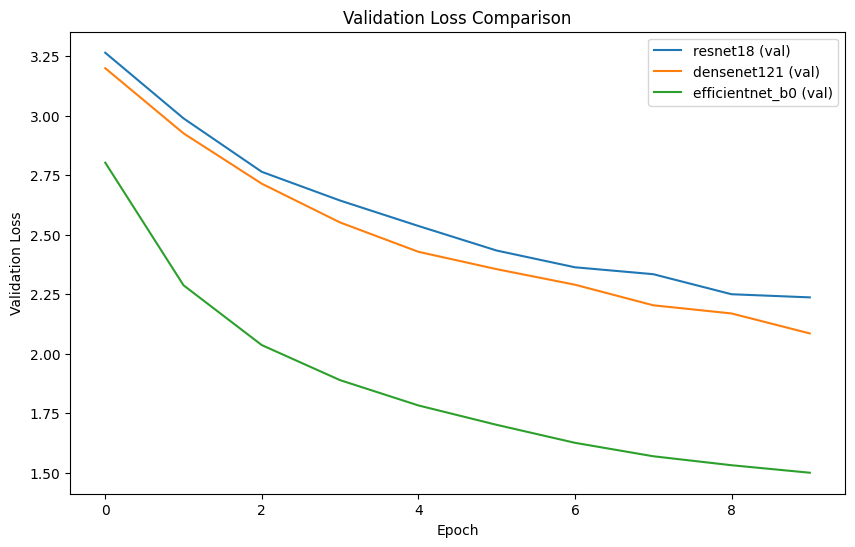

In [ ]:
# Validation loss comparison
plt.figure(figsize=(10,6))
for name, history in histories.items():
    plt.plot(history['val_losses'], label=f"{name} (val)")
plt.xlabel('Epoch'); plt.ylabel('Validation Loss'); plt.title('Validation Loss Comparison'); plt.legend(); plt.show()

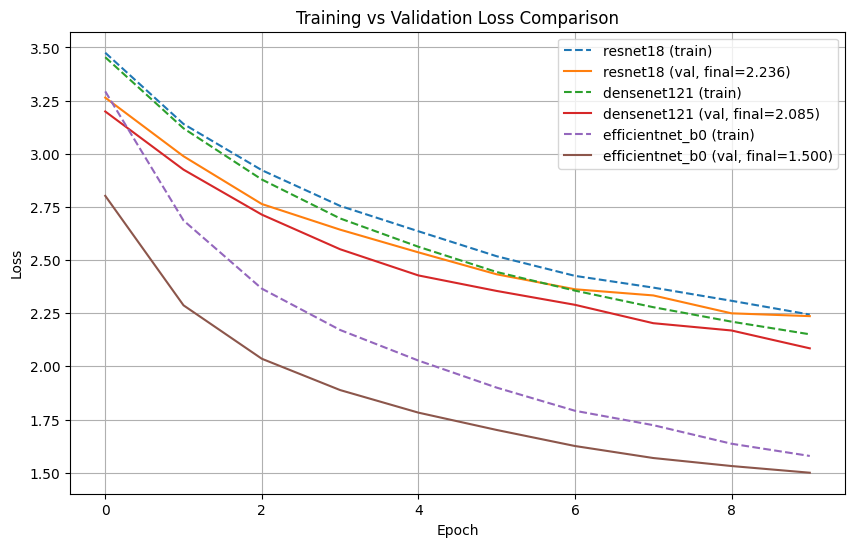

In [ ]:
# Training vs Validation Loss Comparison (with final values)
plt.figure(figsize=(10,6))

for name, history in histories.items():
    train_losses = history.get('train_losses', [])
    val_losses = history.get('val_losses', [])
    final_val_loss = val_losses[-1] if len(val_losses) > 0 else None

    plt.plot(train_losses, linestyle='--', label=f"{name} (train)")
    plt.plot(val_losses, label=f"{name} (val, final={final_val_loss:.3f})")

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss Comparison')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import torch

def evaluate_model(model, dataloader, class_names, device='cuda'):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    print(f"Validation Accuracy: {acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()



Evaluating resnet18
Validation Accuracy: 0.3902

Classification Report:
                    precision    recall  f1-score   support

         Alambadi       1.00      0.22      0.36         9
       Amritmahal       0.00      0.00      0.00         9
         Ayrshire       0.41      0.70      0.52        23
            Banni       0.50      0.22      0.31         9
           Bargur       1.00      0.44      0.62         9
        Bhadawari       0.00      0.00      0.00         8
      Brown_Swiss       0.42      0.59      0.49        22
            Dangi       0.75      0.38      0.50         8
            Deoni       0.00      0.00      0.00         9
              Gir       0.33      0.44      0.38        34
         Guernsey       0.60      0.27      0.38        11
         Hallikar       0.27      0.56      0.36        18
          Hariana       0.00      0.00      0.00        12
Holstein_Friesian       0.60      0.81      0.69        32
       Jaffrabadi       0.67      0.44  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


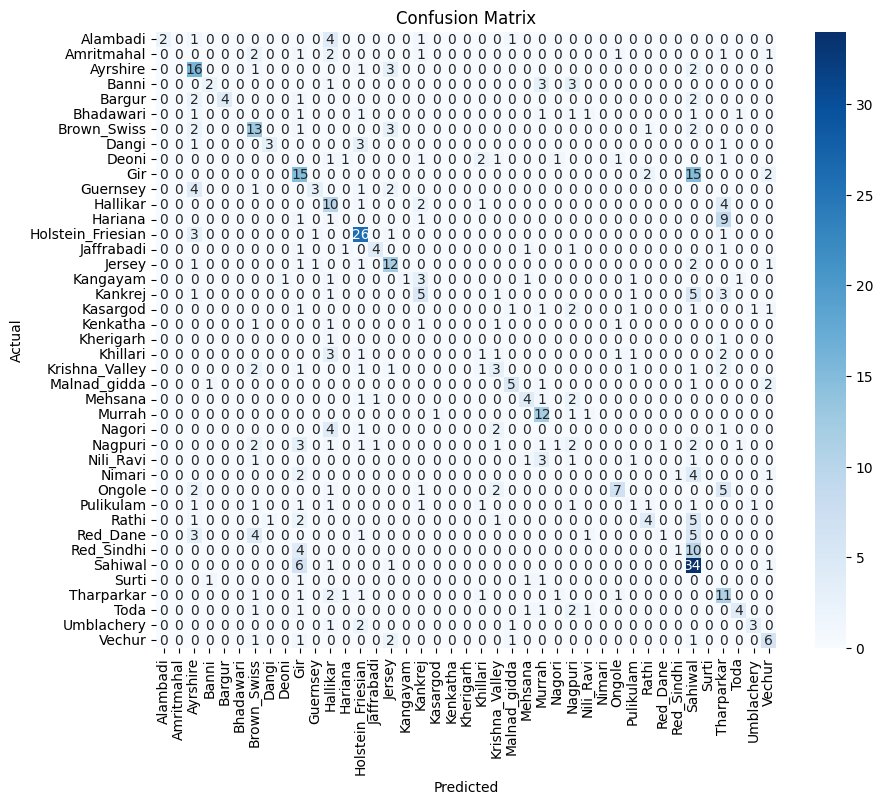

resnet18 acc: 37.93%

Evaluating densenet121
Validation Accuracy: 0.4192

Classification Report:
                    precision    recall  f1-score   support

         Alambadi       0.67      0.22      0.33         9
       Amritmahal       0.00      0.00      0.00         9
         Ayrshire       0.52      0.74      0.61        23
            Banni       0.33      0.33      0.33         9
           Bargur       1.00      0.56      0.71         9
        Bhadawari       1.00      0.12      0.22         8
      Brown_Swiss       0.54      0.68      0.60        22
            Dangi       0.67      0.50      0.57         8
            Deoni       1.00      0.11      0.20         9
              Gir       0.43      0.59      0.50        34
         Guernsey       0.50      0.18      0.27        11
         Hallikar       0.23      0.61      0.33        18
          Hariana       0.50      0.33      0.40        12
Holstein_Friesian       0.53      0.81      0.64        32
       Jaffrabad

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


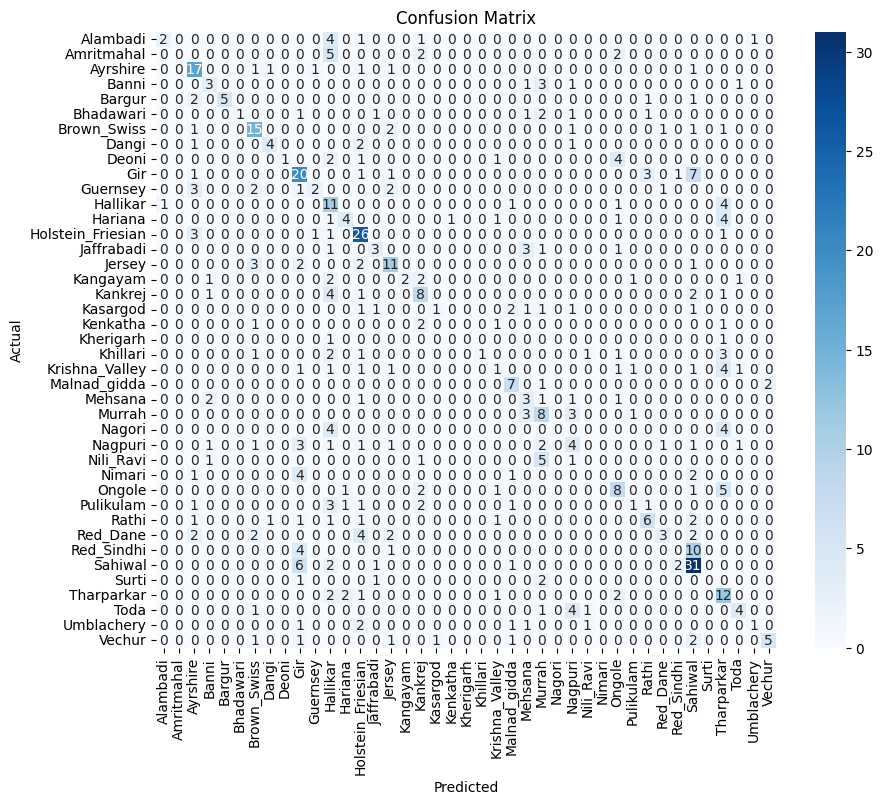

densenet121 acc: 41.38%

Evaluating efficientnet_b0
Validation Accuracy: 0.5517

Classification Report:
                    precision    recall  f1-score   support

         Alambadi       0.71      0.56      0.62         9
       Amritmahal       0.67      0.22      0.33         9
         Ayrshire       0.65      0.74      0.69        23
            Banni       0.33      0.22      0.27         9
           Bargur       0.69      1.00      0.82         9
        Bhadawari       0.25      0.12      0.17         8
      Brown_Swiss       0.70      0.64      0.67        22
            Dangi       0.67      0.75      0.71         8
            Deoni       0.57      0.44      0.50         9
              Gir       0.49      0.88      0.63        34
         Guernsey       0.50      0.55      0.52        11
         Hallikar       0.52      0.67      0.59        18
          Hariana       0.38      0.50      0.43        12
Holstein_Friesian       0.81      0.81      0.81        32
       Ja

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


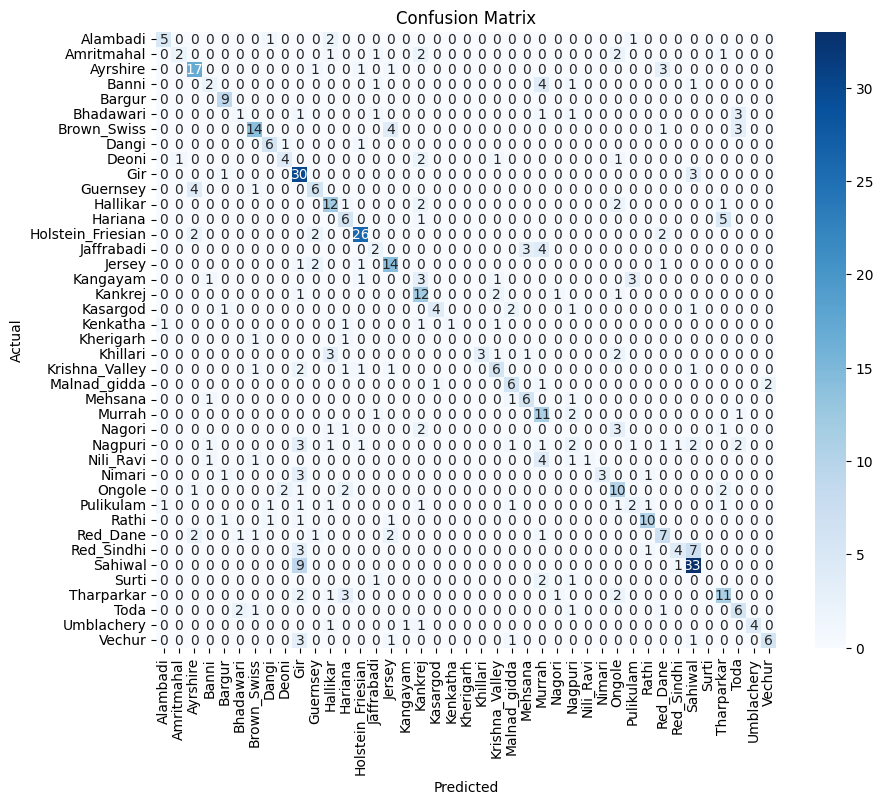

efficientnet_b0 acc: 57.35%

Accuracies: {'resnet18': 37.93103448275862, 'densenet121': 41.37931034482759, 'efficientnet_b0': 57.3502722323049}


In [ ]:
# Evaluate models and show accuracies
from sklearn.metrics import accuracy_score
accuracies = {}
for name, model in trained_models.items():
    print(f"\nEvaluating {name}")
    evaluate_model(model, val_loader, dataset.classes, device=device)
    model.eval()
    preds, labs = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            out = model(imgs)
            _, p = torch.max(out,1)
            preds.extend(p.cpu().numpy()); labs.extend(labels.numpy())
    acc = accuracy_score(labs, preds)
    accuracies[name] = acc*100
    print(f"{name} acc: {acc*100:.2f}%")
print('\nAccuracies:', accuracies)

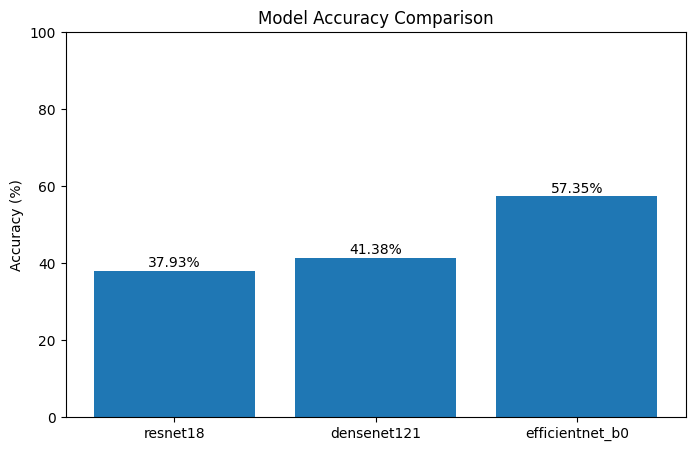

In [ ]:
# Accuracy bar chart
plt.figure(figsize=(8,5))
names = list(accuracies.keys()); vals = [accuracies[n] for n in names]
plt.bar(names, vals); plt.ylabel('Accuracy (%)'); plt.title('Model Accuracy Comparison'); plt.ylim(0,100)
for i,v in enumerate(vals): plt.text(i, v+1, f"{v:.2f}%", ha='center')
plt.show()

Best: efficientnet_b0


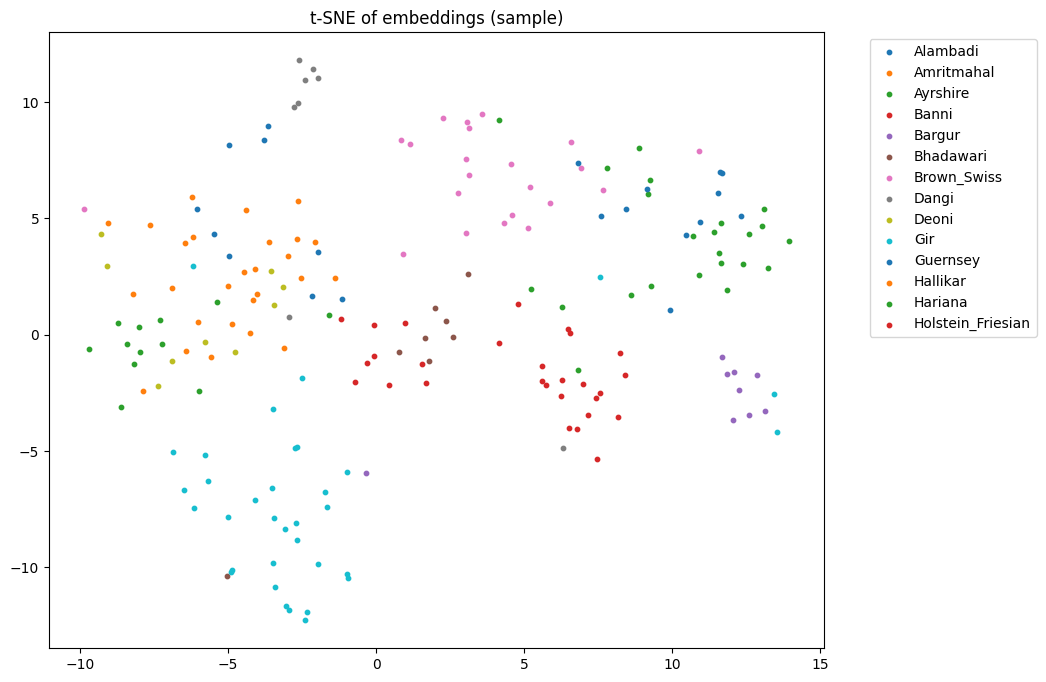

In [ ]:
# Feature extraction and t-SNE for best model (by val loss)
best_name = min(histories, key=lambda k: min(histories[k]['val_losses']))
best_model = trained_models[best_name]
print('Best:', best_name)

import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def extract_embeddings_small(model, dataloader, max_samples=200, device=None):
    if device is None: device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device); model.eval()
    feats, labs = [], []
    try:
        feat_extractor = torch.nn.Sequential(*list(model.children())[:-1])
    except Exception:
        feat_extractor = model
    cnt = 0
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            out = feat_extractor(imgs)
            out = out.view(out.size(0), -1).cpu().numpy()
            feats.append(out); labs.extend(labels.numpy())
            cnt += out.shape[0]
            if cnt >= max_samples:
                break
    feats = np.vstack(feats)[:max_samples]; labs = np.array(labs)[:max_samples]
    return feats, labs

feats, labs = extract_embeddings_small(best_model, val_loader, max_samples=200, device=device)
pca = PCA(n_components=min(50, feats.shape[1])); feats_p = pca.fit_transform(feats)
z = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(feats_p)
plt.figure(figsize=(10,8))
for c in np.unique(labs):
    mask = labs==c
    plt.scatter(z[mask,0], z[mask,1], label=dataset.classes[c], s=10)
plt.legend(bbox_to_anchor=(1.05,1)); plt.title('t-SNE of embeddings (sample)'); plt.show()

Exception ignored in: <function BaseCAM.__del__ at 0x7d8a05b33060>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_grad_cam/base_cam.py", line 212, in __del__
    self.activations_and_grads.release()
    ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'GradCAM' object has no attribute 'activations_and_grads'
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Fallback Grad-CAM (manual). GradCAM.__init__() got an unexpected keyword argument 'use_cuda'


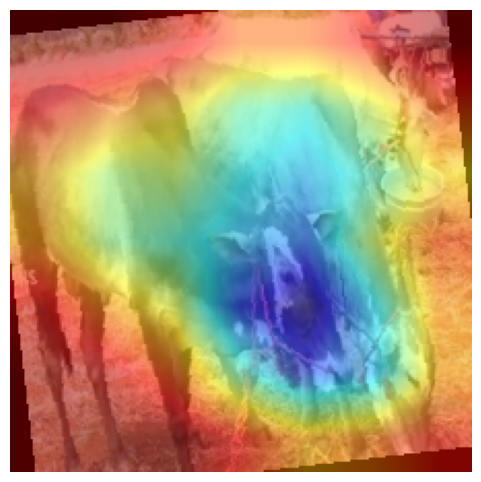

In [ ]:
# Grad-CAM (single sample) - uses package if available, else manual fallback
import cv2, numpy as np
model = best_model.to(device); model.eval()
imgs, labs = next(iter(val_loader)); img = imgs[0].unsqueeze(0).to(device)
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    try:
        target_layer = model.layer4[-1]
    except Exception:
        target_layer = None
        for nm,m in reversed(list(model.named_modules())):
            if isinstance(m, torch.nn.Conv2d):
                target_layer = m; break
    cam = GradCAM(model=model, target_layers=[target_layer], use_cuda=(device.type=='cuda'))
    grayscale_cam = cam(input_tensor=img)[0]
    np_img = img[0].cpu().numpy().transpose(1,2,0)
    img_denorm = (np_img * np.array(imagenet_std) + np.array(imagenet_mean)).clip(0,1)
    vis = show_cam_on_image(img_denorm, grayscale_cam, use_rgb=True)
    plt.figure(figsize=(6,6)); plt.imshow(vis); plt.axis('off'); plt.show()
except Exception as e:
    print('Fallback Grad-CAM (manual).', e)
    grad = {}; act = {}
    def save_grad(module, grad_in, grad_out): grad['val'] = grad_out[0].detach().cpu()
    def save_act(module, inp, out): act['val'] = out.detach().cpu()
    last_conv = None
    for nm,m in reversed(list(model.named_modules())):
        if isinstance(m, torch.nn.Conv2d):
            last_conv = m; break
    if last_conv is None: raise RuntimeError('No conv layer found')
    h1 = last_conv.register_forward_hook(save_act); h2 = last_conv.register_backward_hook(save_grad)
    model.zero_grad(); out = model(img); pred = out.argmax(dim=1).item(); score = out[0, pred]; score.backward()
    activation = act['val'][0]; gradients = grad['val'][0]; weights = gradients.mean(dim=(1,2))
    cam = (weights[:, None, None] * activation).sum(dim=0).numpy(); cam = np.maximum(cam,0)
    cam = (cam - cam.min())/(cam.max()-cam.min()+1e-8)
    heatmap = cv2.resize(cam, (img.shape[3], img.shape[2])); np_img = img[0].cpu().numpy().transpose(1,2,0)
    img_denorm = (np_img * np.array(imagenet_std) + np.array(imagenet_mean)).clip(0,1)
    heatmap = np.uint8(255 * heatmap); heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)/255.0
    overlay = 0.5*img_denorm + 0.5*heatmap; plt.figure(figsize=(6,6)); plt.imshow(overlay); plt.axis('off'); plt.show()
    h1.remove(); h2.remove()

In [ ]:
# === Inference: Test a Single Image (Breed Prediction) ===
import torch
from torchvision import models, transforms
from PIL import Image, UnidentifiedImageError
import requests
from io import BytesIO
import os

# === Step 1. Define path to your checkpoint ===
MODEL_PATH = '/content/drive/MyDrive/resnet18_best_with_history_epoch12.pth'

# === Step 2. Define model architecture ===
model = models.resnet18(weights=None)
num_features = model.fc.in_features
num_classes = 41  # total number of breeds
model.fc = torch.nn.Linear(num_features, num_classes)

# === Step 3. Load checkpoint ===
checkpoint = torch.load(MODEL_PATH, map_location='cpu')
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
model.eval()

print("✅ Model loaded successfully.")
print("Checkpoint keys:", checkpoint.keys() if isinstance(checkpoint, dict) else "state_dict only")

# === Step 4. Define class names (41 cattle breeds) ===
class_names = [
    'Alambadi', 'Amritmahal', 'Ayrshire', 'Banni', 'Bargur', 'Bhadawari',
    'Brown_Swiss', 'Dangi', 'Deoni', 'Gir', 'Guernsey', 'Hallikar', 'Hariana',
    'Holstein_Friesian', 'Jaffrabadi', 'Jersey', 'Kangayam', 'Kankrej',
    'Kasargod', 'Kenkatha', 'Kherigarh', 'Khillari', 'Krishna_Valley',
    'Malnad_gidda', 'Mehsana', 'Murrah', 'Nagori', 'Nagpuri', 'Nili_Ravi',
    'Nimari', 'Ongole', 'Pulikulam', 'Rathi', 'Red_Dane', 'Red_Sindhi',
    'Sahiwal', 'Surti', 'Tharparkar', 'Toda', 'Umblachery', 'Vechur'
]
print(f"📊 Number of classes: {len(class_names)}")

# === Step 5. Define preprocessing transforms ===
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# === Step 6. Helper function for prediction ===
def predict_image(img: Image.Image):
    x = preprocess(img).unsqueeze(0)
    with torch.no_grad():
        preds = model(x)
        probs = torch.nn.functional.softmax(preds, dim=1)
        conf, idx = torch.max(probs, 1)
    print(f"🐮 Predicted Breed: {class_names[idx.item()]} (Confidence: {conf.item():.3f})")

# === Step 7. Predict from URL ===
def predict_from_url(url):
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content)).convert('RGB')
    except (requests.exceptions.RequestException, UnidentifiedImageError) as e:
        print(f"⚠️ Error loading image from URL: {e}")
        return
    predict_image(img)

# === Step 8. Predict from local path ===
def predict_from_path(img_path):
    if not os.path.exists(img_path):
        print(f"⚠️ File not found: {img_path}")
        return
    try:
        img = Image.open(img_path).convert('RGB')
    except UnidentifiedImageError:
        print(f"⚠️ Cannot open image: {img_path}")
        return
    predict_image(img)

# === Step 9. Example usage ===
print("\n--- Example: Predict from URL ---")
predict_from_url("https://shahjighee.com/wp-content/uploads/2022/12/Sahiwal-Cow_600x600.jpg")

# Example for local image (uncomment and set path if needed)
# print("\n--- Example: Predict from local file ---")
# predict_from_path("/content/drive/MyDrive/cattle_images_whole/Sahiwal/image1.jpg")


----

EDA, training, multi-model comparison, t-SNE and Grad-CAM.